In [1]:
# Cell 1 — Imports and global style settings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../data/netflix_titles.csv')

# Global style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 8807 rows, 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
# Cell 2 — Data Cleaning
# Convert date_added to datetime so we can extract year/month
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
df['year_added'] = df['date_added'].dt.year

# Clean duration — split into numeric value and unit separately
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z]+)')

# Remove dirty rating values (same ones we found in SQL)
dirty_ratings = ['74 min', '84 min', '66 min']
df = df[~df['rating'].isin(dirty_ratings)]

# Confirm shape after cleaning
print(f"After cleaning: {df.shape[0]} rows")
print(f"\nYear range: {int(df['year_added'].min())} to {int(df['year_added'].max())}")
print(f"\nMissing year_added: {df['year_added'].isna().sum()} rows")

After cleaning: 8804 rows

Year range: 2008 to 2021

Missing year_added: 10 rows


## Chart 1: Content Growth Over Time
How has Netflix's Movies vs TV Shows addition rate changed year over year?
Excludes pre-2015 years due to insufficient sample size (<30 titles/year).


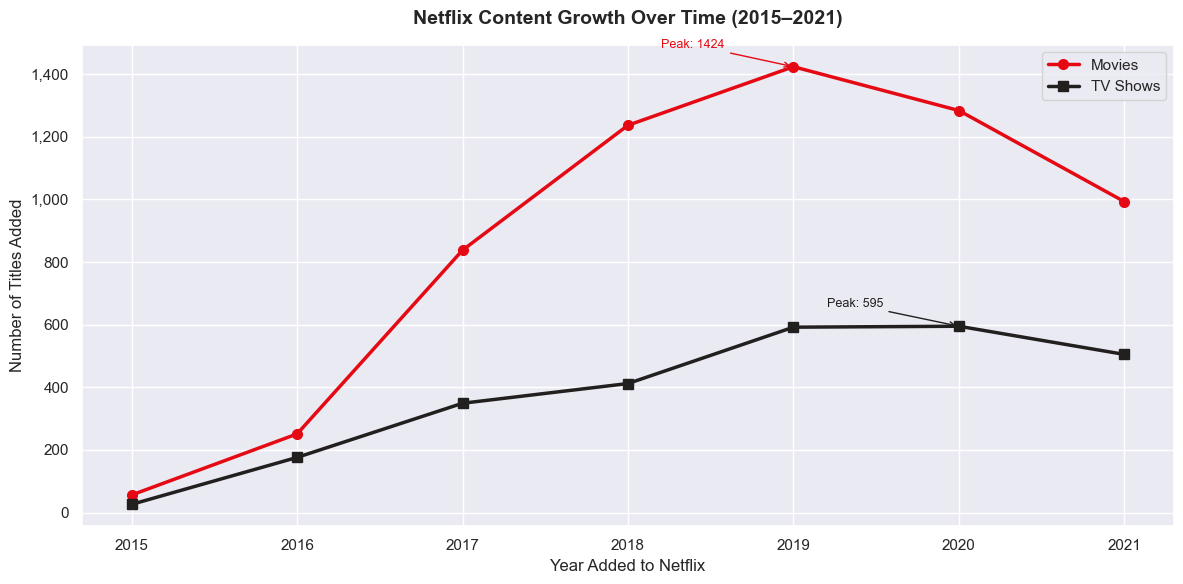

Chart 1 saved.


In [4]:
# Cell 3 — Chart 1: Content Growth Over Time

# Prepare data
growth = (
    df[df['year_added'] >= 2015]
    .groupby(['year_added', 'type'])
    .size()
    .reset_index(name='total_titles')
)

movies = growth[growth['type'] == 'Movie']
tvshows = growth[growth['type'] == 'TV Show']

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(movies['year_added'], movies['total_titles'],
        marker='o', linewidth=2.5, color='#E50914',
        label='Movies', markersize=7)

ax.plot(tvshows['year_added'], tvshows['total_titles'],
        marker='s', linewidth=2.5, color='#221F1F',
        label='TV Shows', markersize=7)

# Annotate peak points
peak_movie = movies.loc[movies['total_titles'].idxmax()]
peak_tv = tvshows.loc[tvshows['total_titles'].idxmax()]

ax.annotate(f"Peak: {int(peak_movie['total_titles'])}",
            xy=(peak_movie['year_added'], peak_movie['total_titles']),
            xytext=(peak_movie['year_added'] - 0.8, peak_movie['total_titles'] + 60),
            fontsize=9, color='#E50914',
            arrowprops=dict(arrowstyle='->', color='#E50914'))

ax.annotate(f"Peak: {int(peak_tv['total_titles'])}",
            xy=(peak_tv['year_added'], peak_tv['total_titles']),
            xytext=(peak_tv['year_added'] - 0.8, peak_tv['total_titles'] + 60),
            fontsize=9, color='#221F1F',
            arrowprops=dict(arrowstyle='->', color='#221F1F'))

# Labels
ax.set_title("Netflix Content Growth Over Time (2015–2021)", pad=15)
ax.set_xlabel("Year Added to Netflix")
ax.set_ylabel("Number of Titles Added")
ax.set_xticks(movies['year_added'])
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../python/charts/chart1_content_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

## Chart 2: Genre Growth — Rising vs Declining (2019–2021 vs Prior Years)
Which genres is Netflix doubling down on, and which is it pulling back from?
Only genres with 100+ prior-year titles included to avoid small-base distortion.

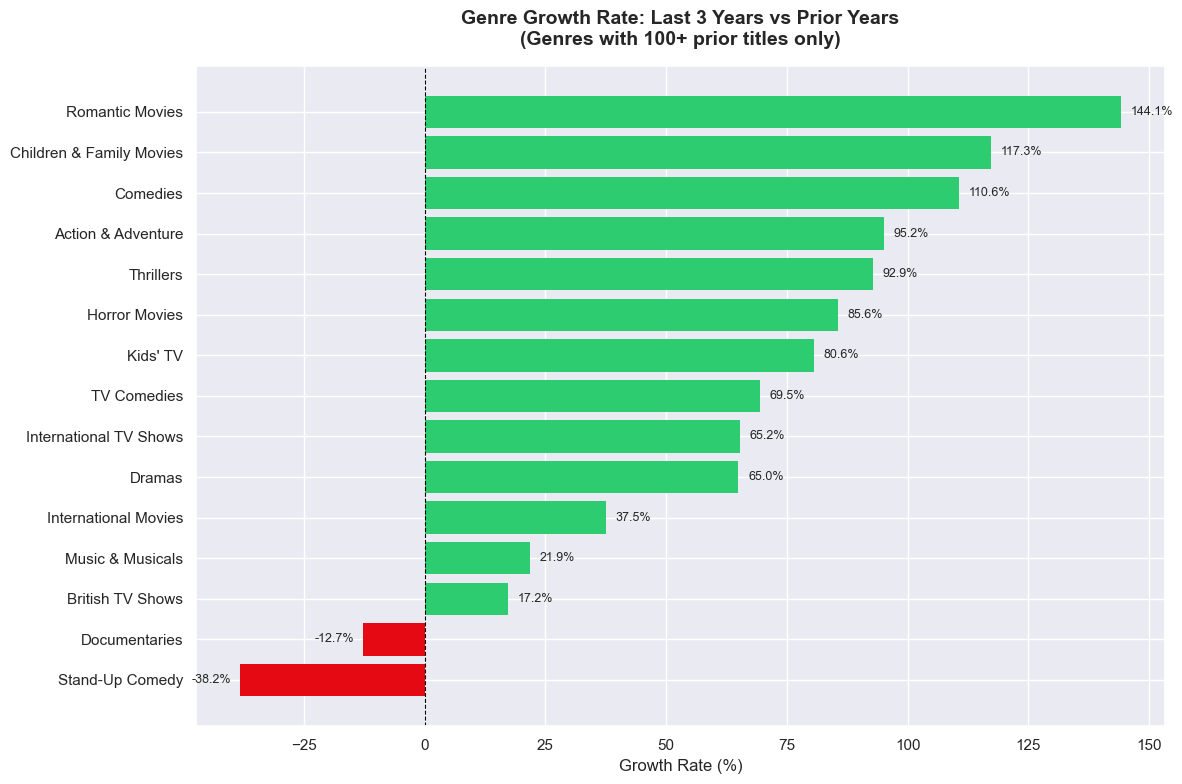

Chart 2 saved.


In [5]:
# Cell 4 — Chart 2: Genre Growth vs Decline

# Explode genres (one row per genre)
genre_df = df[df['year_added'].notna()].copy()
genre_df = genre_df.assign(
    genre=genre_df['listed_in'].str.split(',')
).explode('genre')
genre_df['genre'] = genre_df['genre'].str.strip()

# Split into recent (2019–2021) vs prior
recent = genre_df[genre_df['year_added'] >= 2019].groupby('genre').size()
prior  = genre_df[genre_df['year_added'] <  2019].groupby('genre').size()

growth = pd.DataFrame({'recent_3yr': recent, 'prior_years': prior}).fillna(0)
growth = growth[growth['prior_years'] >= 100]  # meaningful base filter
growth['growth_pct'] = ((growth['recent_3yr'] - growth['prior_years'])
                         / growth['prior_years'] * 100).round(2)

# Top 10 growing, bottom 5 declining
top_growing  = growth.nlargest(10, 'growth_pct')
declining    = growth.nsmallest(5,  'growth_pct')
chart_data   = pd.concat([top_growing, declining]).sort_values('growth_pct')

# Colour: green for growth, red for decline
colors = ['#2ecc71' if x >= 0 else '#E50914'
          for x in chart_data['growth_pct']]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(chart_data.index, chart_data['growth_pct'], color=colors, edgecolor='none')

# Add value labels on bars
for bar, val in zip(bars, chart_data['growth_pct']):
    x_pos = bar.get_width() + (2 if val >= 0 else -2)
    ha     = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha=ha, fontsize=9)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Genre Growth Rate: Last 3 Years vs Prior Years\n(Genres with 100+ prior titles only)', pad=15)
ax.set_xlabel('Growth Rate (%)')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../python/charts/chart2_genre_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

## Chart 3: Content Rating Distribution by Year (2015–2021)
Has Netflix been targeting more mature or family audiences over time?
Ratings grouped into Mature, Teen, and Family tiers for clarity.

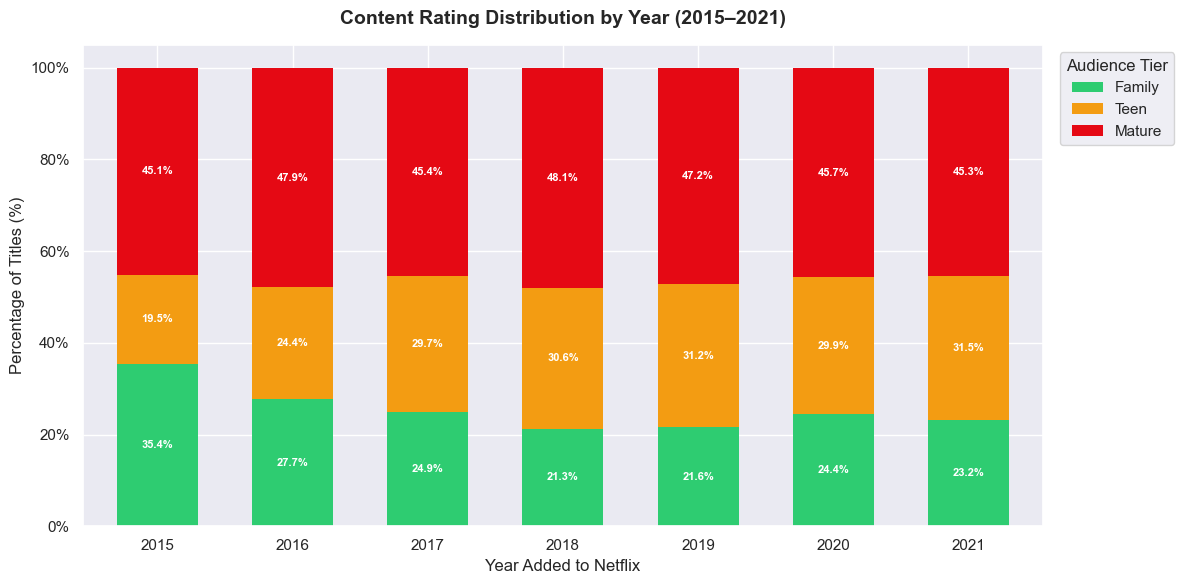

Chart 3 saved.


In [6]:
# Cell 5 — Chart 3: Rating Distribution Shift Over Years

# Define rating buckets
mature_ratings = ['TV-MA', 'R', 'NC-17', 'UR', 'NR']
teen_ratings   = ['TV-14', 'PG-13']
family_ratings = ['TV-G', 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'G', 'PG', 'TV-PG']

def categorise_rating(r):
    if r in mature_ratings: return 'Mature'
    if r in teen_ratings:   return 'Teen'
    if r in family_ratings: return 'Family'
    return None

# Prepare data
rating_df = df[
    df['year_added'].notna() &
    df['rating'].notna() &
    (df['year_added'] >= 2015)
].copy()

rating_df['audience'] = rating_df['rating'].apply(categorise_rating)
rating_df = rating_df[rating_df['audience'].notna()]

# Calculate percentages per year
rating_pivot = (
    rating_df.groupby(['year_added', 'audience'])
    .size()
    .unstack(fill_value=0)
)
rating_pct = rating_pivot.div(rating_pivot.sum(axis=1), axis=0) * 100

# Reorder columns for stacking: Family at bottom, Mature at top
rating_pct = rating_pct[['Family', 'Teen', 'Mature']]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71', '#f39c12', '#E50914']
rating_pct.plot(kind='bar', stacked=True, ax=ax,
                color=colors, edgecolor='none', width=0.6)

# Add percentage labels inside bars
for i, year_row in enumerate(rating_pct.itertuples()):
    bottom = 0
    for j, (col, color) in enumerate(zip(
            ['Family', 'Teen', 'Mature'], colors)):
        val = getattr(year_row, col)
        if val > 5:  # only label if segment is big enough to read
            ax.text(i, bottom + val / 2, f'{val:.1f}%',
                    ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
        bottom += val

ax.set_title('Content Rating Distribution by Year (2015–2021)', pad=15)
ax.set_xlabel('Year Added to Netflix')
ax.set_ylabel('Percentage of Titles (%)')
ax.set_xticklabels([int(x) for x in rating_pct.index], rotation=0)
ax.legend(title='Audience Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('../python/charts/chart3_rating_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

## Chart 4: India vs US Genre Mix Comparison
How does India's content strategy differ from the US?
Top 8 genres by combined volume shown for clarity.

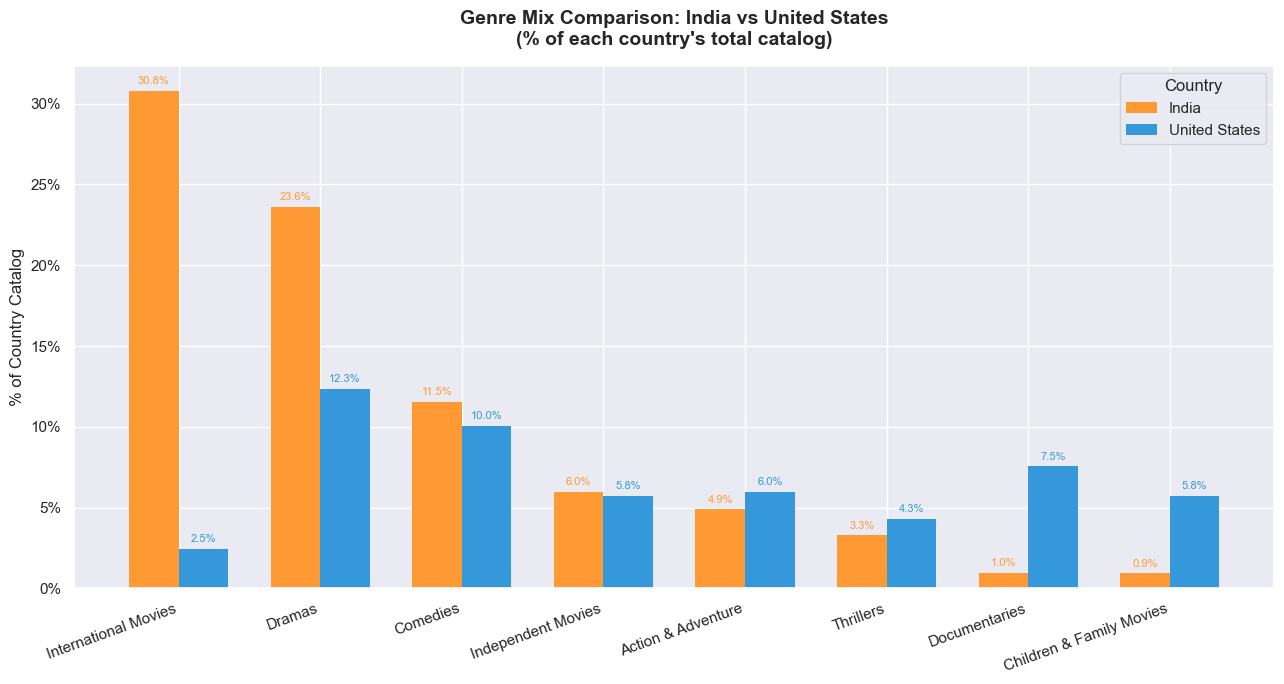

Chart 4 saved.


In [7]:
# Cell 6 — Chart 4: India vs US Genre Mix

# Explode country and genre separately, join on show_id
country_df = df[df['country'].notna()].copy()
country_df = country_df.assign(
    country=country_df['country'].str.split(',')
).explode('country')
country_df['country'] = country_df['country'].str.strip()

genre_exp = df[df['listed_in'].notna()].copy()
genre_exp = genre_exp.assign(
    genre=genre_exp['listed_in'].str.split(',')
).explode('genre')
genre_exp['genre'] = genre_exp['genre'].str.strip()

# Join on show_id — same safe pattern as SQL Q4/Q5
merged = country_df[['show_id', 'country']].merge(
    genre_exp[['show_id', 'genre']], on='show_id'
)

# Filter to India and US only
comparison = merged[merged['country'].isin(['India', 'United States'])]

# Count per country per genre
genre_counts = (
    comparison.groupby(['country', 'genre'])
    .size()
    .reset_index(name='count')
)

# Calculate percentage within each country
genre_counts['country_total'] = genre_counts.groupby('country')['count'].transform('sum')
genre_counts['pct'] = (genre_counts['count'] / genre_counts['country_total'] * 100).round(2)

# Pick top 8 genres by combined volume across both countries
top_genres = (
    genre_counts.groupby('genre')['count']
    .sum()
    .nlargest(8)
    .index
)
chart_data = genre_counts[genre_counts['genre'].isin(top_genres)]

# Pivot for grouped bar chart
pivot = chart_data.pivot(index='genre', columns='country', values='pct').fillna(0)
pivot = pivot.sort_values('India', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(13, 7))

x = range(len(pivot))
width = 0.35

bars_india = ax.bar([i - width/2 for i in x], pivot['India'],
                     width=width, label='India',
                     color='#FF9933', edgecolor='none')
bars_us    = ax.bar([i + width/2 for i in x], pivot['United States'],
                     width=width, label='United States',
                     color='#3498db', edgecolor='none')

# Value labels on bars
for bar in bars_india:
    if bar.get_height() > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=8, color='#FF9933')

for bar in bars_us:
    if bar.get_height() > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=8, color='#3498db')

ax.set_title('Genre Mix Comparison: India vs United States\n(% of each country\'s total catalog)', pad=15)
ax.set_xlabel('')
ax.set_ylabel('% of Country Catalog')
ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index, rotation=20, ha='right')
ax.legend(title='Country')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('../python/charts/chart4_india_vs_us.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

## Chart 5: TV Show Season Distribution
Does Netflix favour limited series or long-running franchises?
67% of TV Shows have only one season — revealing Netflix's low-commitment content strategy.

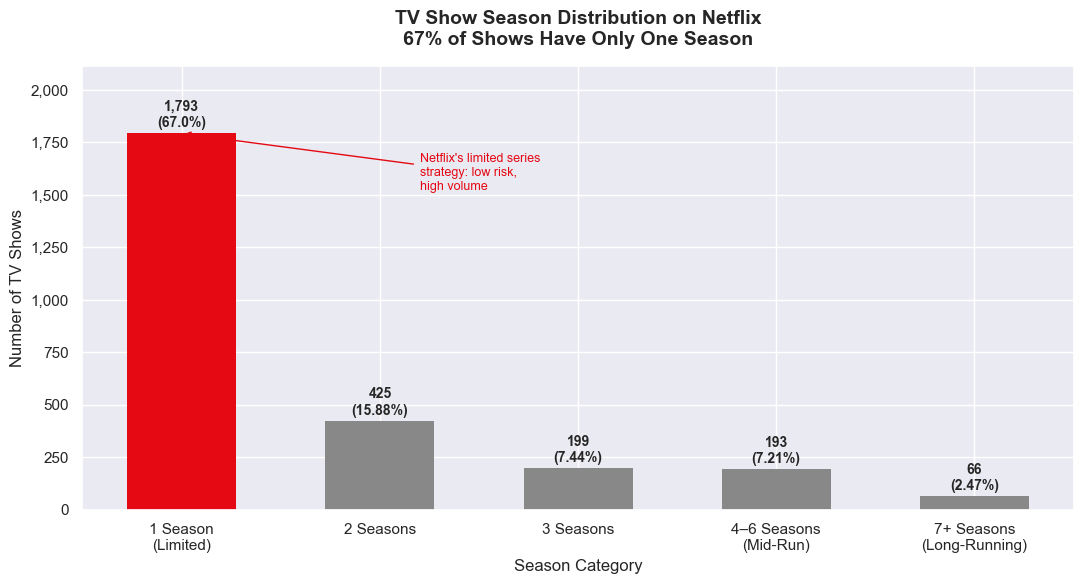

Chart 5 saved.


In [8]:
# Cell 7 — Chart 5: TV Show Season Distribution

# Filter TV Shows only, extract season count
season_df = df[
    (df['type'] == 'TV Show') &
    (df['duration_value'].notna())
].copy()

season_df['season_count'] = season_df['duration_value'].astype(int)

# Categorise into buckets
def categorise_seasons(n):
    if n == 1:            return '1 Season\n(Limited)'
    elif n == 2:          return '2 Seasons'
    elif n == 3:          return '3 Seasons'
    elif 4 <= n <= 6:     return '4–6 Seasons\n(Mid-Run)'
    else:                 return '7+ Seasons\n(Long-Running)'

season_df['category'] = season_df['season_count'].apply(categorise_seasons)

# Define order explicitly
order = ['1 Season\n(Limited)', '2 Seasons', '3 Seasons',
         '4–6 Seasons\n(Mid-Run)', '7+ Seasons\n(Long-Running)']

counts = season_df['category'].value_counts().reindex(order)
pcts   = (counts / counts.sum() * 100).round(2)

# Colours — highlight the dominant bar
bar_colors = ['#E50914' if i == 0 else '#888888' for i in range(len(order))]

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(order, counts, color=bar_colors, edgecolor='none', width=0.55)

# Value labels above bars
for bar, pct, count in zip(bars, pcts, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 15,
            f'{count:,}\n({pct}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("TV Show Season Distribution on Netflix\n67% of Shows Have Only One Season", pad=15)
ax.set_xlabel('Season Category')
ax.set_ylabel('Number of TV Shows')
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add annotation explaining the strategic implication
ax.annotate(
    'Netflix\'s limited series\nstrategy: low risk,\nhigh volume',
    xy=(0, counts.iloc[0]),
    xytext=(1.2, counts.iloc[0] * 0.85),
    fontsize=9, color='#E50914',
    arrowprops=dict(arrowstyle='->', color='#E50914')
)

plt.tight_layout()
plt.savefig('../python/charts/chart5_season_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

## Summary of Key Visual Findings

1. **Content peaked in 2019** — Movies hit 1,424 titles then dropped 30%. TV Shows proved more resilient, declining only 15% from peak.
2. **Romantic Movies grew 144%** — the fastest-growing meaningful genre. Stand-Up Comedy declined 38% — the sharpest fall.
3. **Mature content is stable, not growing** — stays at 45-48% every year. The real shift is Family content declining as Teen content rises.
4. **India concentrates in 3 genres (66% of catalog)** — US spreads across 8+ genres evenly. India has almost no Documentaries (1%) vs US (7.5%).
5. **67% of Netflix TV Shows have only 1 season** — reveals a deliberate low-risk, high-volume limited series commissioning strategy.